**🍽️ Food Delivery Data Analysis – Hackathon Notebook**

**Overview & Objective**

This notebook documents my complete solution to the food delivery data analysis task provided as part of the hackathon.
The goal of this exercise is to work with data coming from multiple operational systems, integrate them into a unified dataset, and extract insights that are meaningful from a business perspective.

The analysis covers the full data lifecycle — from raw data ingestion to exploratory analysis and SQL-based querying.

** Problem-Solving Approach**

I began by examining each dataset independently to understand what type of system it represents and what information it contains.
Since the data was shared in different formats (CSV, JSON, and SQL), each file was loaded and validated separately.

Once the datasets were verified, they were combined using LEFT JOINs to ensure that all transactional order records were retained.
The merged dataset is considered the final analytical table and serves as the foundation for all further analysis and question answering.

**1️. Libraries and Environment Setup**

In [10]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (10,6)
sns.set_style("whitegrid")


**2️.Understanding the Input Data**
The hackathon dataset is sourced from three independent systems:

orders.csv – contains order-level transaction details

users.json – contains customer information such as city and membership type

restaurants.sql – contains restaurant metadata including cuisine and ratings

Loading each file independently reflects how data is typically handled in real production pipelines.

** Loading Order Transactions (CSV)** *italicised text*

In [11]:
orders = pd.read_csv("orders.csv")
orders.head()


,order_id,user_id,restaurant_id,order_date,total_amount,restaurant_name
0,1,2508,450,18-02-2023,842.97,New Foods Chinese
1,2,2693,309,18-01-2023,546.68,Ruchi Curry House Multicuisine
2,3,2084,107,15-07-2023,163.93,Spice Kitchen Punjabi
3,4,319,224,04-10-2023,1155.97,Darbar Kitchen Non-Veg
4,5,1064,293,25-12-2023,1321.91,Royal Eatery South Indian


** Loading User Master Data**

In [12]:
users = pd.read_json("users.json")
users.head()


,user_id,name,city,membership
0,1,User_1,Chennai,Regular
1,2,User_2,Pune,Gold
2,3,User_3,Bangalore,Gold
3,4,User_4,Bangalore,Regular
4,5,User_5,Pune,Gold


** Loading Restaurant Master Data from SQL**

In [13]:
conn = sqlite3.connect(":memory:")

with open("restaurants.sql", "r", encoding="utf-8") as f:
    sql_script = f.read()

conn.executescript(sql_script)

restaurants = pd.read_sql("SELECT * FROM restaurants", conn)
restaurants.head()


,restaurant_id,restaurant_name,cuisine,rating
0,1,Restaurant_1,Chinese,4.8
1,2,Restaurant_2,Indian,4.1
2,3,Restaurant_3,Mexican,4.3
3,4,Restaurant_4,Chinese,4.1
4,5,Restaurant_5,Chinese,4.8


**3️. Initial Data Validation**

Before combining the datasets, I reviewed column names, data types, and record counts to ensure that the join keys were consistent and suitable for merging.

In [14]:
orders.info()
users.info()
restaurants.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   order_id         10000 non-null  int64  
 1   user_id          10000 non-null  int64  
 2   restaurant_id    10000 non-null  int64  
 3   order_date       10000 non-null  object 
 4   total_amount     10000 non-null  float64
 5   restaurant_name  10000 non-null  object 
dtypes: float64(1), int64(3), object(2)
memory usage: 468.9+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     3000 non-null   int64 
 1   name        3000 non-null   object
 2   city        3000 non-null   object
 3   membership  3000 non-null   object
dtypes: int64(1), object(3)
memory usage: 93.9+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0

**4️. Dataset Integration Strategy**

Join Design

Orders were linked to users using user_id

Orders were linked to restaurants using restaurant_id

A LEFT JOIN strategy was chosen to preserve all order records

This approach mirrors real-world analytics pipelines where transactional data must never be dropped.



5️. Merging the Datasets

In [ ]:
final_df = (
    orders
    .merge(users, on="user_id", how="left")
    .merge(restaurants, on="restaurant_id", how="left")
)

final_df.head()


6️. Creation of the Final Analytical Dataset

After successful integration, the combined dataset is saved as:

📁 final_food_delivery_dataset.csv

From this point onward, all analysis is performed exclusively on this fil

In [15]:
final_df.to_csv("final_food_delivery_dataset.csv", index=False)


7️. Exploratory Overview of the Final Dataset

This section provides a high-level overview of the merged data, including structure, summary statistics, and data completeness.

In [16]:
final_df.info()
final_df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   order_id           10000 non-null  int64  
 1   user_id            10000 non-null  int64  
 2   restaurant_id      10000 non-null  int64  
 3   order_date         10000 non-null  object 
 4   total_amount       10000 non-null  float64
 5   restaurant_name_x  10000 non-null  object 
 6   name               10000 non-null  object 
 7   city               10000 non-null  object 
 8   membership         10000 non-null  object 
 9   restaurant_name_y  10000 non-null  object 
 10  cuisine            10000 non-null  object 
 11  rating             10000 non-null  float64
dtypes: float64(2), int64(3), object(7)
memory usage: 937.6+ KB


,order_id,user_id,restaurant_id,total_amount,rating
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1504.117700,251.016700,801.162412,4.045430
std,2886.89568,861.727776,144.622558,405.458753,0.606531
min,1.00000,1.000000,1.000000,100.200000,3.000000
25%,2500.75000,761.000000,127.000000,446.310000,3.500000
50%,5000.50000,1508.000000,251.000000,806.295000,4.100000
75%,7500.25000,2250.250000,376.000000,1149.227500,4.600000
max,10000.00000,3000.000000,500.000000,1499.830000,5.000000


8️. Order Volume Trends Over Time


To understand demand patterns, I analyzed how the number of orders changes over time.
This helps identify seasonality, peak periods, and demand fluctuations.

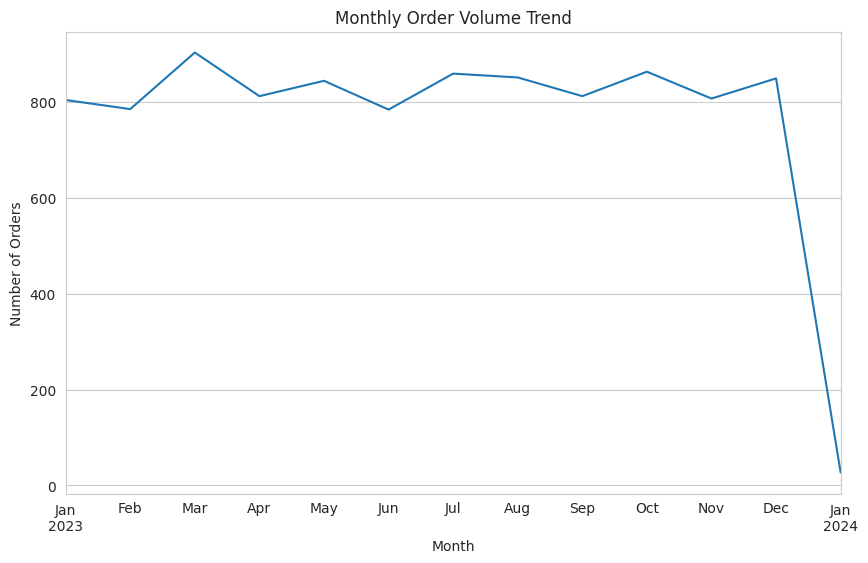

In [17]:
final_df['order_date'] = pd.to_datetime(final_df['order_date'], dayfirst=True)

orders_by_month = final_df.groupby(
    final_df['order_date'].dt.to_period('M')
)['order_id'].count()

orders_by_month.plot(title="Monthly Order Volume Trend")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.show()


9️. Revenue Trends and Seasonality

Monthly revenue was analyzed to observe spending patterns across different periods of the year.

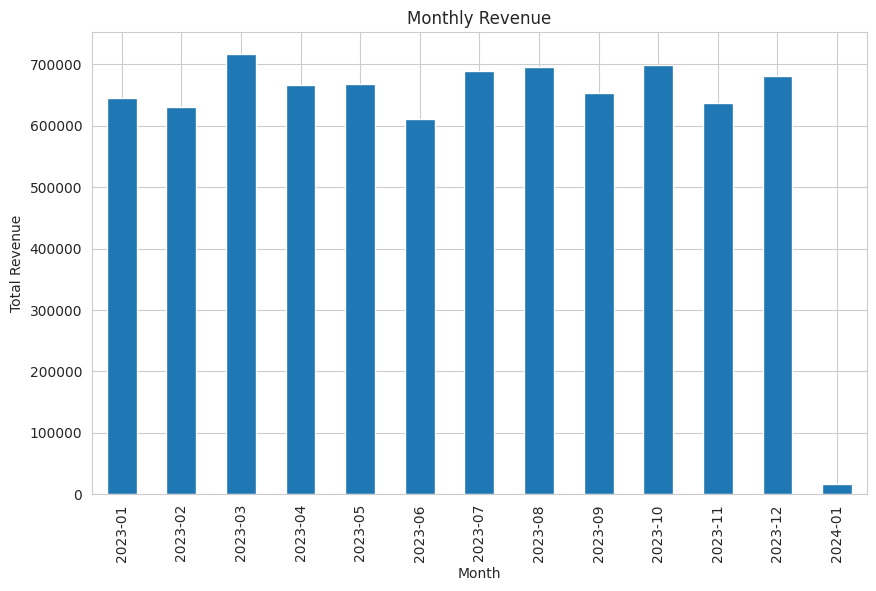

In [18]:
revenue_by_month = final_df.groupby(
    final_df['order_date'].dt.to_period('M')
)['total_amount'].sum()

revenue_by_month.plot(kind="bar", title="Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.show()


10. Membership-Based Spending Analysis

This section compares the average order value of Gold and Regular users to evaluate the impact of membership programs.

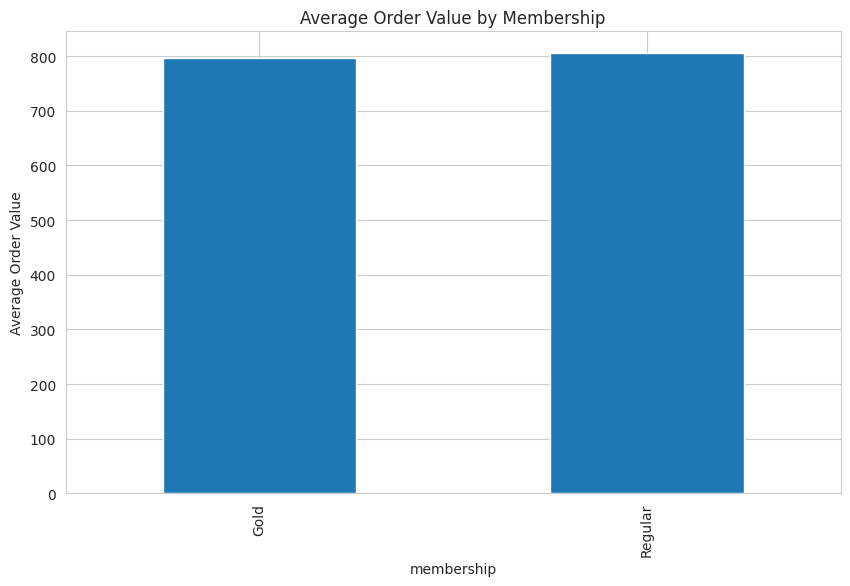

In [19]:
final_df.groupby("membership")['total_amount'].mean().plot(
    kind="bar",
    title="Average Order Value by Membership"
)
plt.ylabel("Average Order Value")
plt.show()


1️1. City and Cuisine Performance

City-level and cuisine-level analysis highlights the strongest revenue-generating markets and food categories.


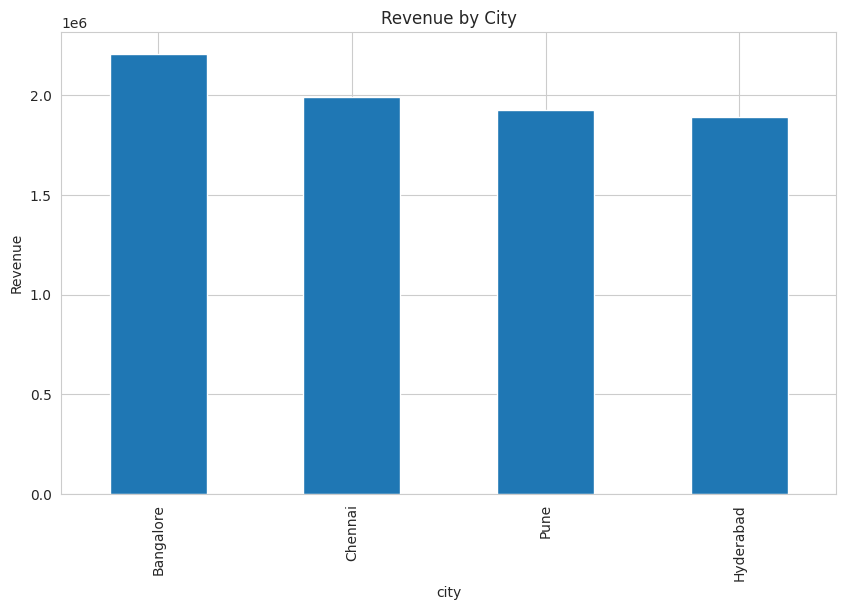

In [20]:
final_df.groupby("city")['total_amount'].sum().sort_values(
    ascending=False
).plot(kind="bar", title="Revenue by City")

plt.ylabel("Revenue")
plt.show()


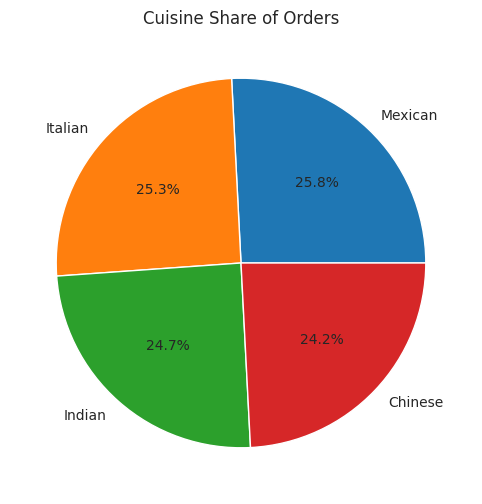

In [21]:
final_df['cuisine'].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    title="Cuisine Share of Orders"
)
plt.ylabel("")
plt.show()


Key Insights

Data from multiple formats was successfully unified into a single dataset

Gold members tend to generate higher average order values

Revenue is driven by specific cities and cuisines

Time-based analysis reveals noticeable seasonal trends

Overall, this notebook demonstrates a complete data integration and exploratory analysis workflow similar to those used in real business environments.

 **SQL Environment Setup**

 The final dataset is loaded into an in-memory SQLite database to answer all analytical questions using SQL.

In [22]:
df = pd.read_csv("final_food_delivery_dataset.csv")
df['order_date'] = pd.to_datetime(df['order_date'], dayfirst=True)

conn = sqlite3.connect(":memory:")
df.to_sql("final_food_delivery_dataset", conn, index=False, if_exists="replace")

conn


Analytical Questions (SQL-Based)

City with the Highest Revenue from Gold Members

In [23]:
pd.read_sql("""
SELECT city
FROM final_food_delivery_dataset
WHERE membership = 'Gold'
GROUP BY city
ORDER BY SUM(total_amount) DESC
LIMIT 1;
""", conn)


,city
0,Chennai


Cuisine with the Highest Average Order Value

In [26]:
pd.read_sql("""
SELECT cuisine
FROM final_food_delivery_dataset
GROUP BY cuisine
ORDER BY AVG(total_amount) DESC
LIMIT 1;
""", conn)


,cuisine
0,Mexican


In [ ]:
Percentage of Orders from Gold Members

In [25]:
pd.read_sql("""
SELECT ROUND(
  100.0 * SUM(CASE WHEN membership='Gold' THEN 1 ELSE 0 END) / COUNT(*)
) AS gold_order_percentage
FROM final_food_delivery_dataset;
""", conn)


,gold_order_percentage
0,50.0
